In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

AUC no conjunto de teste: 0.6582
                       Variável  Importância média  Desvio padrão  \
1                    taxa_juros           0.106505       0.002142   
6                  renda_mensal           0.018539       0.001660   
3                   escore_fico           0.014976       0.003077   
0              valor_financiado           0.009784       0.002848   
2          tempo_relacionamento           0.003277       0.001757   
5  registros_publicos_negativos           0.003151       0.000942   
4          inadimplencia_2_anos           0.002926       0.000965   
7         finalidade_emprestimo           0.001334       0.001582   

                  Variável Plot  
1                 Taxa de Juros  
6                  Renda Mensal  
3                   Escore FICO  
0              Valor Financiado  
2       Tempo de Relacionamento  
5  Registros Públicos Negativos  
4        Inadimplência (2 anos)  
7      Finalidade do Empréstimo  


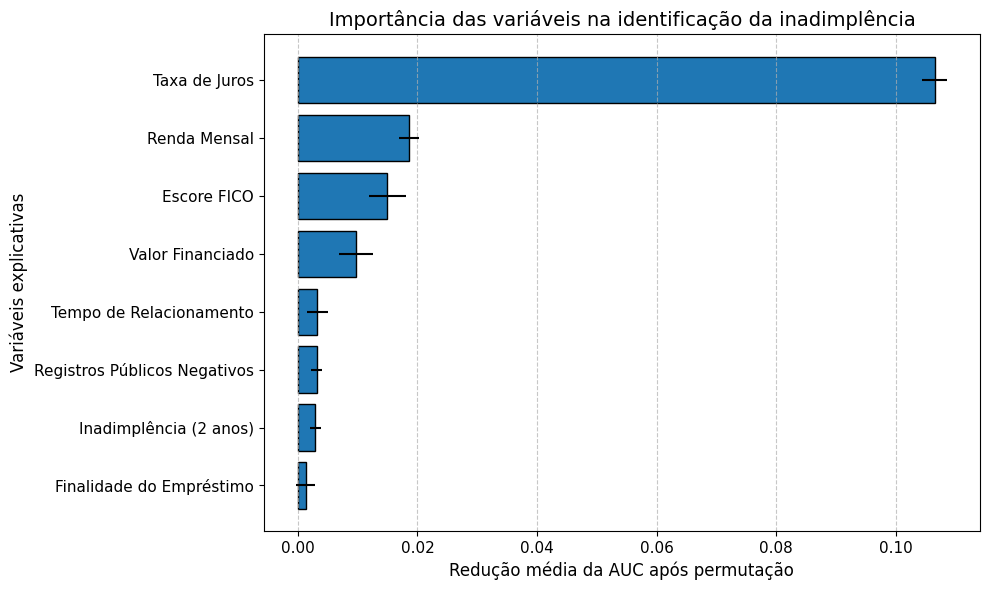

In [6]:
# =========================
# 1. Carregar dados
# =========================
df = pd.read_csv("amostra_estratificada.csv", sep=";")

# =========================
# 2. Definir variáveis
# =========================
features_num = [
    "valor_financiado",
    "taxa_juros",
    "tempo_relacionamento",
    "escore_fico",
    "inadimplencia_2_anos",
    "registros_publicos_negativos",
    "renda_mensal"
]

features_cat = ["finalidade_emprestimo"]

nomes_variaveis = {
    "valor_financiado": "Valor Financiado",
    "taxa_juros": "Taxa de Juros",
    "tempo_relacionamento": "Tempo de Relacionamento",
    "escore_fico": "Escore FICO",
    "inadimplencia_2_anos": "Inadimplência (2 anos)",
    "registros_publicos_negativos": "Registros Públicos Negativos",
    "renda_mensal": "Renda Mensal",
    "finalidade_emprestimo": "Finalidade do Empréstimo"
}

target = "default"

X = df[features_num + features_cat].copy()
y = df[target].astype(int)

# =========================
# 3. Separar treino e teste
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# =========================
# 4. Pré-processamento
# =========================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), features_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), features_cat)
    ]
)

# =========================
# 5. Modelo escolhido
# =========================
modelo = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", modelo)
])

# =========================
# 6. Treinar modelo
# =========================
pipeline.fit(X_train, y_train)

y_prob = pipeline.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)

print(f"AUC no conjunto de teste: {auc:.4f}")

# =========================
# 7. Permutation Importance
# =========================
perm_importance = permutation_importance(
    pipeline,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importancias = pd.DataFrame({
    "Variável": X_test.columns,
    "Importância média": perm_importance.importances_mean,
    "Desvio padrão": perm_importance.importances_std
})

# Aplicar nomes mais amigáveis para o gráfico
importancias["Variável Plot"] = importancias["Variável"].map(nomes_variaveis)

# Caso alguma variável não esteja no dicionário, mantém o nome original
importancias["Variável Plot"] = importancias["Variável Plot"].fillna(importancias["Variável"])

importancias = importancias.sort_values(
    by="Importância média",
    ascending=False
)

print(importancias)

# Salvar tabela
importancias.to_csv("importancia_variaveis_permutation.csv", sep=";", index=False)

# =========================
# 8. Gráfico de importância
# =========================
plt.figure(figsize=(10, 6))

plt.barh(
    importancias["Variável Plot"],
    importancias["Importância média"],
    xerr=importancias["Desvio padrão"],
    edgecolor="black"
)

plt.gca().invert_yaxis()

plt.title(
    "Importância das variáveis na identificação da inadimplência",
    fontsize=14
)

plt.xlabel("Redução média da AUC após permutação", fontsize=12)
plt.ylabel("Variáveis explicativas", fontsize=12)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig(
    "./figuras/importancia_variaveis_permutation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()